In [36]:
# intialization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Parameters for identifying events
S_THRESH = 1.6 # gradient threshold [ ] -> this is a unitless value that represents the rate of change in discharge, thus controlling the length of the rising and falling limb of the extracted flood hydrographs
Q_THRESH = 177.9 # peak discharge threshold [m3/s] -> minimum discharge required for an event to be considered a flood event
T_LAG = 3 # time lag between events [days]

# I/O file paths
INPUT_FILE = '../data/discharge.csv' # discharge time series with columns: Year, Mon, Day, Hour, Discharge; should not have missing data!
OUTPUT_FILE = '../data/out_python.csv' # output file path for storing identified events with columns event_id,y,m,d,h,discharge

# 1. Read the CSV 
# Pandas automatically uses the first row as headers and starts data from the second row
df_in = pd.read_csv(INPUT_FILE)

# 2. Convert to datetime using the column names in the input file
# rename them to what pd.to_datetime expects (year, month, day, hour)
df_in['datetime'] = pd.to_datetime(df_in[['Year', 'Mon', 'Day', 'Hour']].rename(
    columns={
        'Year': 'year', 
        'Mon': 'month', 
        'Day': 'day', 
        'Hour': 'hour'
    }
))

# 3. print the discharge data read into python
print(df_in[['datetime', 'Discharge']].head())


             datetime  Discharge
0 1950-01-01 00:00:00   1.348784
1 1950-01-01 01:00:00   4.306151
2 1950-01-01 02:00:00   8.032187
3 1950-01-01 03:00:00  11.678648
4 1950-01-01 04:00:00  15.029928


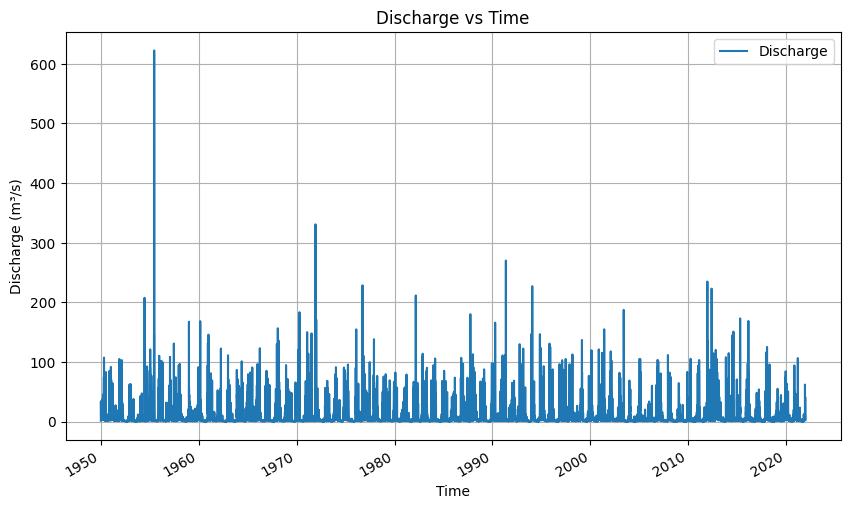

In [37]:
# Plot discharge vs datetime
df_in.plot(x='datetime', y='Discharge', figsize=(10, 6))
plt.title('Discharge vs Time')
plt.xlabel('Time')
plt.ylabel('Discharge (m³/s)')
plt.grid(True)
plt.legend(['Discharge'], loc='best')
plt.show()

In [38]:
# call the flood_hydrograph function to identify flood events
# Note: the function flood_hydrograph.py need to be in the same directory as this script
# Note 2: the "!" is used to run a shell command from within a Jupyter notebook or Python script. It allows you to execute the command as if you were running it in the terminal. In this case, it runs the flood_hydrograph.py script with the specified parameters.
!python flood_hydrograph.py -s {S_THRESH} -q {Q_THRESH} -t {T_LAG} -i {INPUT_FILE} -o {OUTPUT_FILE}

-------------- command-line arguments:
  low gradient threshold:                    1.600
  peak flow threshold:                       177.900
  time lag between independent peaks (days): 3
  input:                                     ../data/discharge.csv
  output:                                    ../data/out_python.csv
-------------- data import (preview of first 10 rows):
     y      m      d      h    value
  1950      1      1      0    1.349
  1950      1      1      1    4.306
  1950      1      1      2    8.032
  1950      1      1      3   11.679
  1950      1      1      4   15.030
  1950      1      1      5   18.243
  1950      1      1      6   21.439
  1950      1      1      7   24.596
  1950      1      1      8   27.560
  1950      1      1      9   30.111
-------------- discharge data import: Done!
-------------- discharge gradient computed: Done!
-------------- flood peaks extraction: Done!
-------------- flood event hydrograph separation: ...
Event_id  id_start  

number of events found: 12


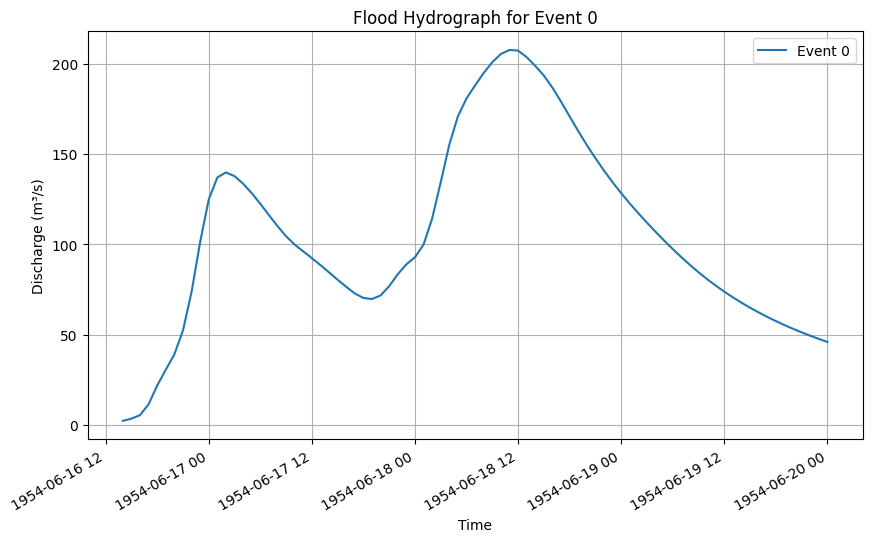

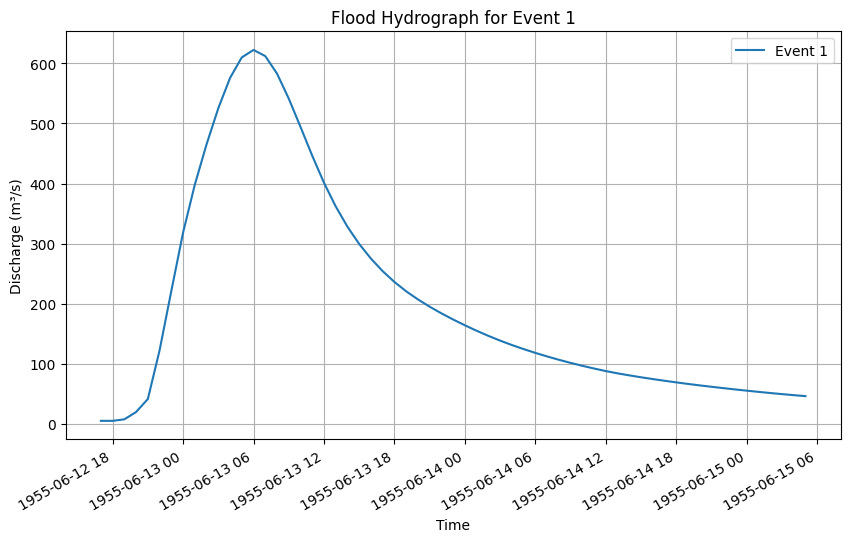

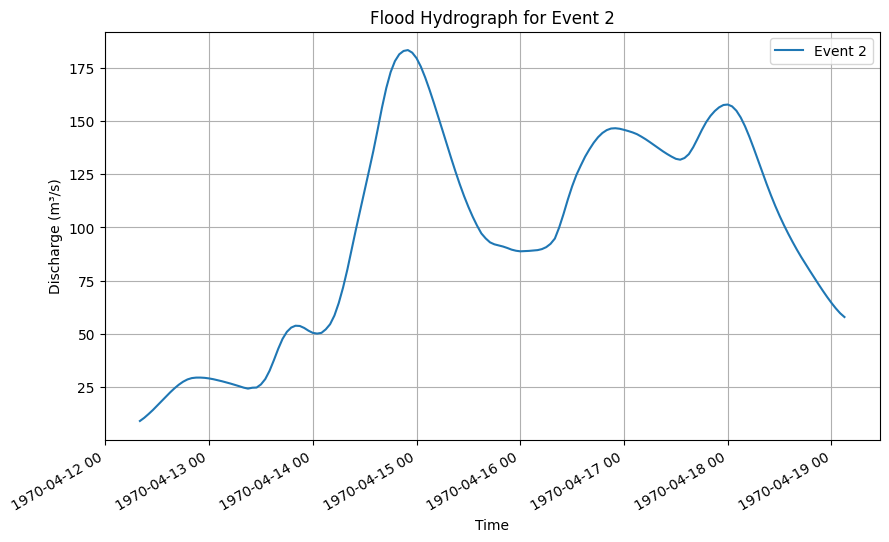

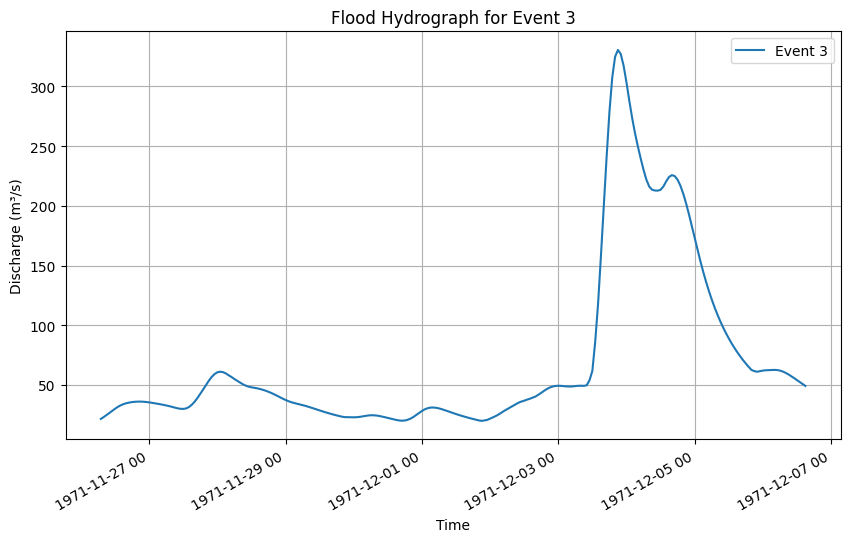

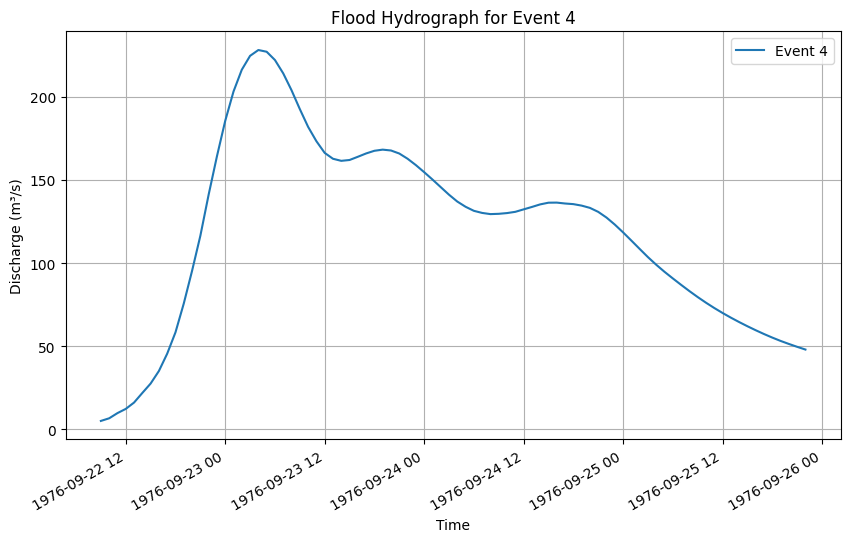

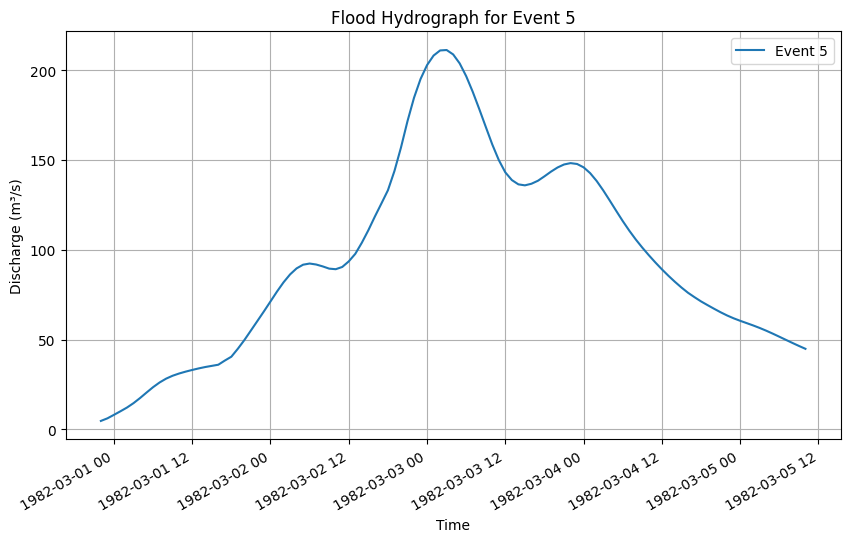

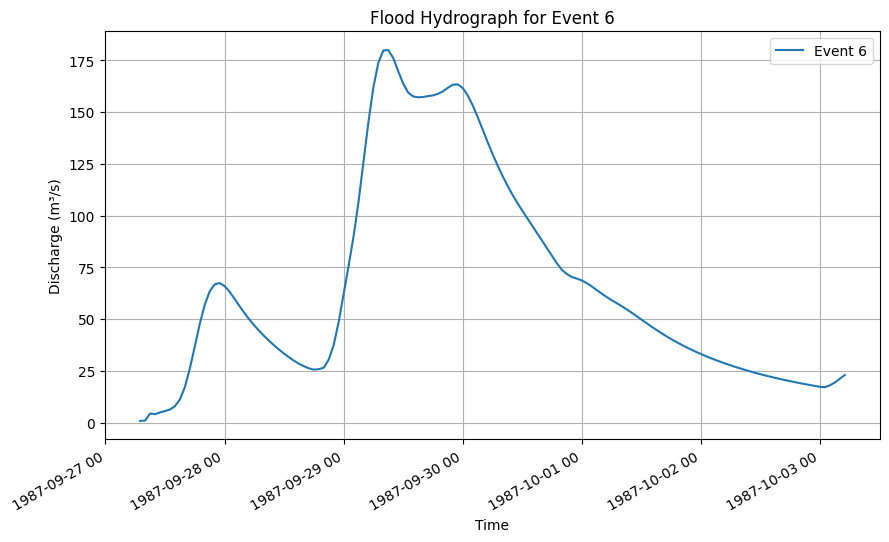

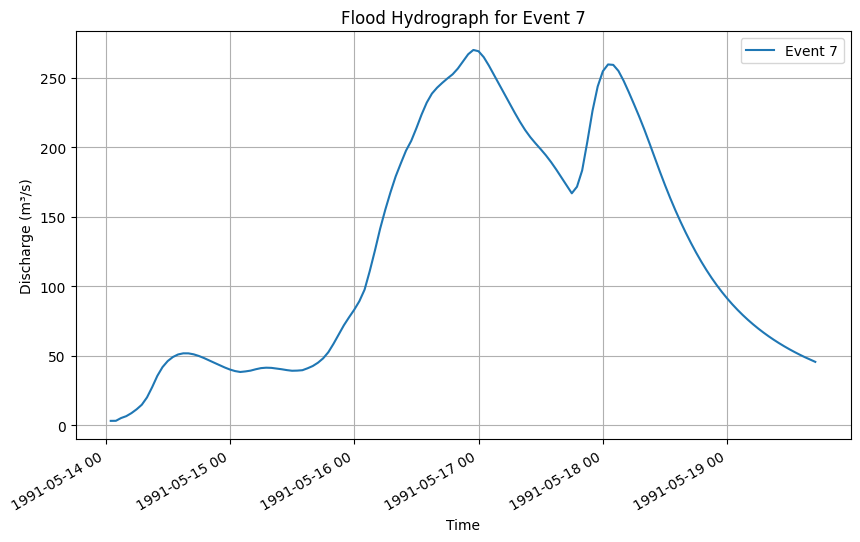

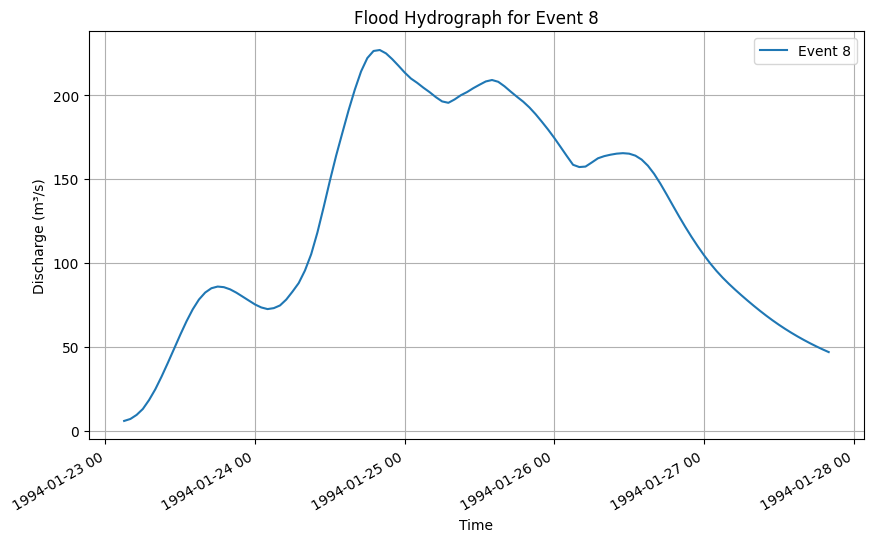

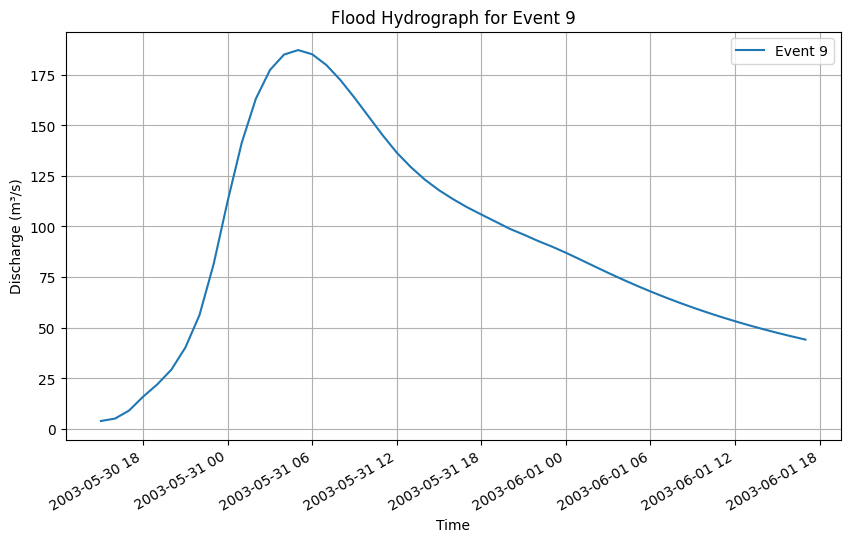

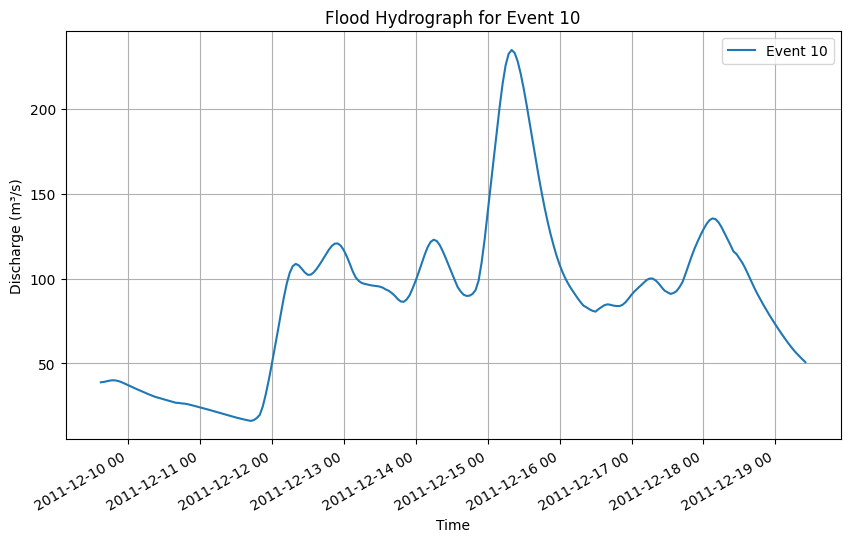

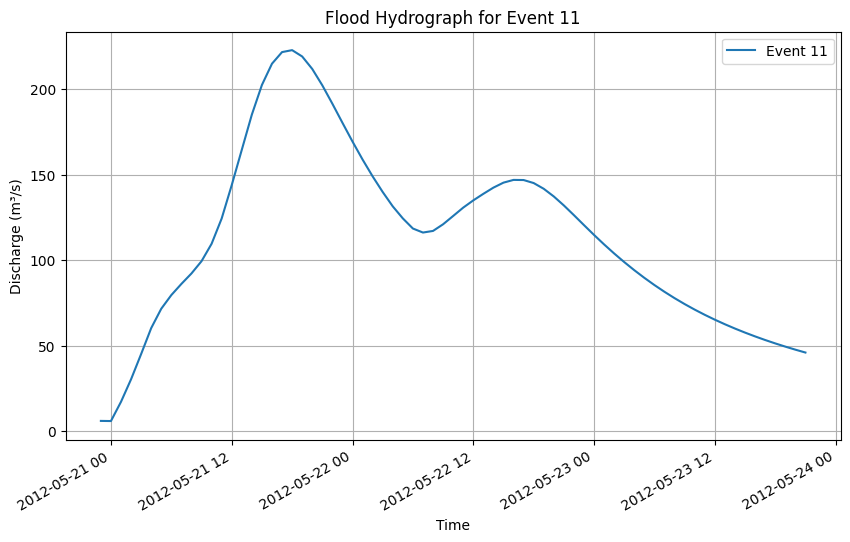

In [39]:
# plot the output flood event hydrographs
df_out = pd.read_csv(OUTPUT_FILE)
#print(df_out.columns)

# Convert to datetime using your exact column names
# rename them to what pd.to_datetime expects (year, month, day, hour)
df_out['datetime'] = pd.to_datetime(df_out[['y', 'm', 'd', 'h']].rename(
    columns={
        'y': 'year', 
        'm': 'month', 
        'd': 'day', 
        'h': 'hour'
    }
))
#print(df_out.columns)

# Create a plot for each unique event_id
unique_events = df_out['event_id'].unique()
print(f'number of events found: {len(unique_events)}')

for event in unique_events:
    event_data = df_out[df_out['event_id'] == event]
    plt.figure(figsize=(10, 6))
    plt.plot(event_data['datetime'], event_data['discharge'], label=f'Event {event}')
    plt.title(f'Flood Hydrograph for Event {event}')
    plt.xlabel('Time')
    plt.ylabel('Discharge (m³/s)')
    plt.grid(True)
    plt.legend(loc='best')
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
    plt.gcf().autofmt_xdate()  # Rotate date labels for better readability
    plt.show()

